# pexl Python model: read, inspect, modify, export

This notebook demonstrates the basic workflow of the Python-side PEExcel model:

1. Read an Excel export into the `Project` / `District` / `Scenario` model
2. Inspect the hierarchical structure
3. Access scenario values and schema metadata
4. Modify a scenario value in Python
5. Write the updated project back to a new Excel file

The example uses an existing PEExcel export workbook as input.

In [1]:
%load_ext autoreload
%autoreload 2
from pexl import Project


## 1. Read an example project workbook

We start by reading an existing Excel export.  
This creates a `Project` object with nested `District` and `Scenario` objects.

In [2]:
from pathlib import Path

project = Project.from_excel(Path("../data/exports/ka_project_backup_v1_11_4.xlsx"))
project

<Project districts=28 warnings=66 source='..\\data\\exports\\ka_project_backup_v1_11_4.xlsx'>

## 2. Basic project overview

The project object is the top-level container.  
It stores:

- the source file path
- all districts
- warnings collected during import

In [3]:
print(project)
print("District count:", len(project.districts))
print("Warning count:", len(project.warnings))

<Project districts=28 warnings=66 source='..\\data\\exports\\ka_project_backup_v1_11_4.xlsx'>
District count: 28
Warning count: 66


In [4]:
project.warnings[:10]

["Column 'Default': district name 'Default' does not match project_name='AT_GWBg'",
 "Column 'Default': scenario name 'Default' does not match project_scenario_name='nach 2020 - existing - Erdgas'",
 "Column 'Gründerzeit | Ausgangslage Gas': district name 'Gründerzeit' does not match project_name='AT_GWBg'",
 "Column 'Gründerzeit | Ausgangslage Gas': scenario name 'Ausgangslage Gas' does not match project_scenario_name='nach 2020 - existing - Erdgas'",
 "Column 'Gründerzeit | thermisch Saniert + Fernwärme': scenario name 'thermisch Saniert + Fernwärme' does not match project_scenario_name='Ausgangslage Gas'",
 "Column 'AT_EFHo | bis 1944 - existing - Erdgas': district name 'AT_EFHo' does not match project_name='Neues Projekt'",
 "Column 'AT_EFHo | bis 1944 - existing - Erdgas': scenario name 'bis 1944 - existing - Erdgas' does not match project_scenario_name='Ausgangsvariante'",
 "Column 'Südtiroler Siedlung | Planung': district name 'Südtiroler Siedlung' does not match project_name='N

The warning list is useful for identifying inconsistencies between:

- scenario column names in Excel
- values stored inside the imported scenario itself  
  (for example `project_name` or `project_scenario_name`)

## 3. Navigate the hierarchy

The data model is intentionally simple:

- `Project` contains multiple `District`s
- each `District` contains multiple `Scenario`s
- each `Scenario` contains values (`scenario.v`) and metadata (`scenario.meta`)

In [5]:
project.districts[:10]

[<District 'Default' scenarios=1>,
 <District 'Gründerzeit' scenarios=3>,
 <District 'Volksschule Neubau' scenarios=1>,
 <District 'Wohnen Neubau 2.5 Geschosse' scenarios=1>,
 <District 'mg. Wohnbau 90er Sanierung' scenarios=1>,
 <District 'Mischnutzung Neubau 7-stöckig' scenarios=1>,
 <District 'AT_EFHo' scenarios=1>,
 <District 'Südtiroler Siedlung' scenarios=1>,
 <District 'EFHo' scenarios=5>,
 <District 'EFHk' scenarios=5>]

Districts and Scenarios can be directly accessed from the parent by their name, or by their index in the list:

In [6]:
district = project["EFHo"]
district2 = project.districts[1]
district, district2

(<District 'EFHo' scenarios=5>, <District 'Gründerzeit' scenarios=3>)

In [7]:
district.scenarios

[<Scenario 'bis 1944 - existing - Erdgas'>,
 <Scenario '1945 - 1989 - existing - Erdgas'>,
 <Scenario '1990 - 1999 - existing - Erdgas'>,
 <Scenario '2000 - 2020 - existing - Erdgas'>,
 <Scenario 'nach 2020 - existing - Erdgas'>]

In [8]:
s0 = district["bis 1944 - existing - Erdgas"]
s4 = district["nach 2020 - existing - Erdgas"]

s0, s4

(<Scenario 'bis 1944 - existing - Erdgas'>,
 <Scenario 'nach 2020 - existing - Erdgas'>)

## 4. Access scenario values directly

All variables can be accessed via dot notation on `scenario.v`. These emcopass all Excel named variables listed in Sheets `IN` and `OUT` 

Their name is identical to their excel name, also found in the respective `var_name` column. This is the most direct interface when the variable name or parts of it is known.  

In [9]:
print("Project/district name:", s0.v.project_name)
print("Scenario:", s0.name)
print("Description:", s0.v.project_description)
print("Total GFA:", s0.v.GFA_total)

Project/district name: EFHo
Scenario: bis 1944 - existing - Erdgas
Description: Einstöckiges Einfamilienhaus /offene Bauweise
Total GFA: 171.48


The schema metadata is  using the same variable names and is available in parallel via `scenario.meta`.
This is helpful for labels, units, semantic grouping, and generic downstream tooling.

In [10]:
s0.meta.GFA_total

<VarMeta 🏙️ GFA_total [m²] @IN>

In [11]:
vars(s0.meta.GFA_total)

{'var_name': 'GFA_total',
 'attr_name': 'GFA_total',
 'icon': '🏙️',
 'label_de': 'BGF Quartier',
 'unit': 'm²',
 'comment': None,
 'source': 'IN',
 'ka': 0,
 'domain': 'usage',
 'measure': 'area',
 'spatial_scope': 'GFA',
 'temporal_scope': None,
 'entity_group': None,
 'entity_key': None}

## 5. Use `ScenarioView` for structured access

The `ScenarioView` API provides filtered, metadata-aware access to named scenario variables.

Useful entry points are:

- `scenario.inn` → input variables defined in excel sheet `IN`
- `scenario.out` → output variables defined in excel sheet `OUT`
- `scenario.view` → all variables

This will probably be extended in the future, and might have already been.

In [12]:
s0.inn

<ScenarioView('bis 1944 - existing - Erdgas', n=607, source=IN)>

In [13]:
s0.inn.domains()

['Battery',
 'Construction',
 'Cooling',
 'DHW',
 'Flexibility',
 'GHG',
 'Heating',
 'Mobility',
 'PV',
 'Solar Gains',
 'Space Use',
 'Thermal Hull',
 'Ventilation',
 'assessment',
 'declaration',
 'district',
 'geometry',
 'lca',
 'mobility',
 'primary_energy',
 'project',
 'tool',
 'usage']

In [14]:
s0.inn.entity_groups()

['component',
 'cooling',
 'dhw',
 'energy_carrier',
 'heating',
 'hull',
 'mobility',
 'usage']

In [15]:
usage_view = s0.inn.by(entity_group="usage", entity_key="residential")
usage_view

<ScenarioView('bis 1944 - existing - Erdgas', n=25, source=IN, filters={ entity_group='usage', entity_key='residential' })>

In [16]:
usage_view.to_var_dict()

{'GFA_residential': 171.48,
 'NFA_to_GFA_ratio_residential': 0.8,
 'NFA_residential': 137.184,
 'renovation_ratio_residential': 0,
 'rh_residential': 2.65,
 'fc_residential': 1,
 'illuminance_min_residential': 300,
 'vent_share_mechanical_residential': 0,
 'vent_night_residential': 'geöffnet',
 'vent_ach_max_residential': 0.40000000000005964,
 'vent_scale_residential': 1.000000000000149,
 'Ev_scale_residential': 1,
 'vent_heat_recovery_winter_residential': 0,
 'vent_heat_recovery_summer_residential': 0,
 'usage_concurrency_winter_residential': 1,
 'usage_concurrency_summer_residential': 1,
 'DHW_demand_residential_kWhm2': 15.975,
 'aux_el_demand_residential_kWhm2': 1.7520000000002613,
 'Plugloads_scale_residential': 1.3,
 'density_NFApPers_residential': 41.7,
 'cool_share_residential': 0,
 'DHW_1_share_residential': 1,
 'DHW_occupancy_residential': 41.7,
 'DHW_concurrency_residential': 0.1,
 'StatPAX_residential': 3.28978417266187}

In [17]:
s0.inn.by(domain="PV").to_var_dict()


{'PV_is_used': 0,
 'PV_profile_name': 'Roof tilt: 15° (Vienna)',
 'PV_id': 41,
 'PV_scale': 9.3,
 'PV_efficiency': 0.9,
 'PV_m2_per_kWp': 5,
 'PV_kWp': 9.3,
 'PV_module_area': 46.5}

This is especially useful for generic processing tasks such as:

- selecting all variables of a certain entity group
- plotting grouped inputs
- exporting subsets
- comparing scenarios

In [18]:
s0.out.domains()

['comfort',
 'electricity_dispatch',
 'electricity_end_use',
 'energy_dispatch',
 'final_energy',
 'heat_balance',
 'pe_import_export_balance',
 'primary_energy_balance',
 'primray_energy',
 'useful_energy',
 'weather']

The `scenario.view.by(*).items()` gives `(Meta: Value)` pairs for consumption

<Axes: >

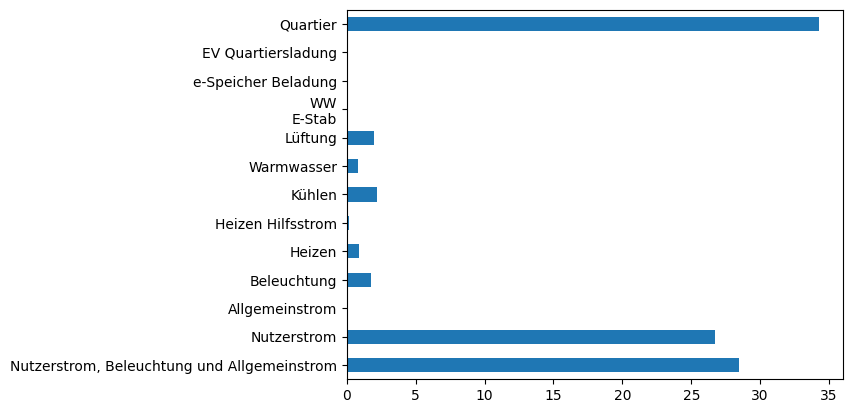

In [28]:
final_energy = s4.out.by(domain="electricity_end_use")
import pandas
diagram_components = {meta.label_de: value for meta, value in final_energy.items()}
pandas.Series(diagram_components).plot(kind="barh")


## 6. Compare two scenarios

Since all scenarios share the same schema-defined variables, comparisons are straightforward.


In [20]:
d0 = s0.inn.to_var_dict()
d1 = s4.inn.to_var_dict()

for var_name, v0 in d0.items():
    v1 = d1.get(var_name)
    if v0 != v1:
        print(f"{var_name:50s}  {round(v0,2):10.2f}   {round(v1,2):10.2f}")

NFV_u                                                   363.54         0.00
NFV_c                                                     0.00       363.54
hull_ext_wall_wo_window_m2                              147.68       138.34
hull_windows_north_m2                                     1.17         2.25
hull_windows_east_m2                                      2.78         5.35
hull_windows_south_m2                                     3.34         6.45
hull_windows_west_m2                                      2.78         5.35
hull_window_m2                                           10.06        19.40
hull_fenestration_rate                                    0.06         0.12
hull_m2                                                 500.70       500.70
hull_transmittance_walls                                  1.35         0.08
hull_transmittance_roof                                   1.28         0.10
hull_transmittance_fundament                              1.06         0.10
hull_transmi

## 7. Modify a scenario in Python

Next, we change one input value directly in the Python object model.

For demonstration, we modify one usage area input in one scenario.

In [21]:
scenario_edit = district["nach 2020 - existing - Erdgas"]

print("Before:", scenario_edit.v.GFA_office)

Before: 0


In [22]:
scenario_edit.v.GFA_office = 250.0

print("After:", scenario_edit.v.GFA_office)

After: 250.0


Because the model stores values as Python attributes, direct modification is simple.

In a larger workflow, this can be combined with:

- scripted scenario generation
- parameter sweeps
- batch edits
- consistency checks before export

## 9. Create a new project
`Project`s do not need to be sourced from an existing Project Excel file, they can also be created.
This allows pexl to group Scenarios and Districts more freely to one or more Projects, which is not possible in Excel.

In [23]:
new_project = Project()
new_project

<Project districts=0 warnings=0>

`District`s can also be created, but it is preferred to do it as part of a project assignment like so. This creates the desired District, if it does not already exists

In [24]:

new_district = new_project.get_or_create_district("Test District")
new_project.districts

[<District 'Test District' scenarios=0>]

Since `Scenarios` are driven by actual data, they should be derived from existing scenarios, such as a `Default` Scenario, or a Type representing a typical combination  of Geometry and Energy System:

In [25]:
scenario_edit.name = "New Scenario"
new_district.add_scenario(scenario_edit, overwrite=True)
print(new_district.scenarios, f"{new_district.scenarios[0].v.GFA_office  = }")

[<Scenario 'New Scenario'>] new_district.scenarios[0].v.GFA_office  = 250.0


## 8. Write the modified project back to Excel

We now export the full project back to an Excel workbook.

The current writer creates an Excel-style `IN` sheet with:

- schema/meta columns first
- one scenario column per scenario
- scenario column names in the form  
  `district_name | scenario_name`

In [26]:
new_project.to_excel("../data/exports/new_project.xlsx")

WindowsPath('../data/exports/new_project.xlsx')

In [27]:
s0.out.by(domain="primary_energy_balance").to_var_dict()

{'PEI_demand': 631.2936527318876,
 'PEI_el_plugloads': 50.778439296307276,
 'PEI_el_hvac': 26.29139225887027,
 'PEI_district_heating': 0,
 'PEI_natural_gas': 554.2238211767101,
 'PEI_biomass': 0,
 'PEI_other': 0,
 'PEI_mob_total': 0,
 'PEI_mob_fossile': 0,
 'PEI_mob_el': 0,
 'PEI_storage_losses': 0,
 'PEI_cf_density': -103.03146990740741,
 'PEI_cf_mobility': 0,
 'PEI_cf_renovation': 0,
 'PEI_sub_PV': 0,
 'PEI_sub_flex': 0,
 'PEI_balance': -734.325122639295}